In [1]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

In [3]:
!pip install prophet statsmodels

In [4]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv"
)

print(df.head())

     Month  Sales
0  1960-01   6550
1  1960-02   8728
2  1960-03  12026
3  1960-04  14395
4  1960-05  14587


In [5]:
df.columns=['Date','Sales']

df['Date']=pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

df.head()

,Sales
Date,
1960-01-01,6550
1960-02-01,8728
1960-03-01,12026
1960-04-01,14395
1960-05-01,14587


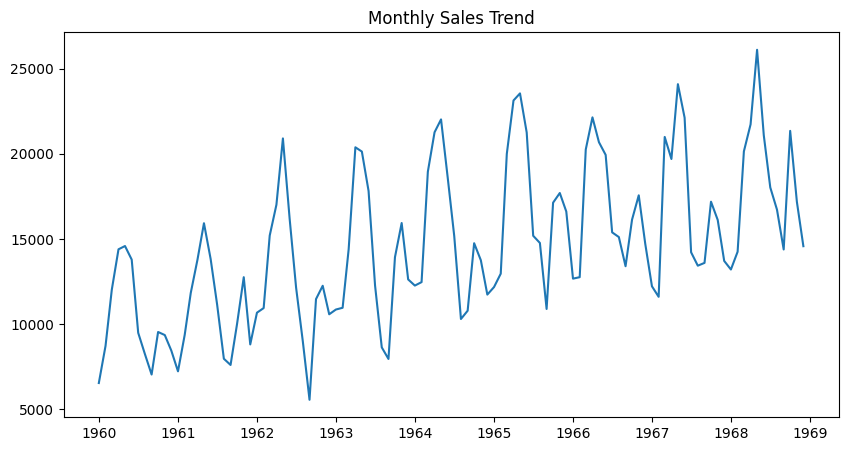

In [6]:
plt.figure(figsize=(10,5))
plt.plot(df['Sales'])
plt.title('Monthly Sales Trend')
plt.show()

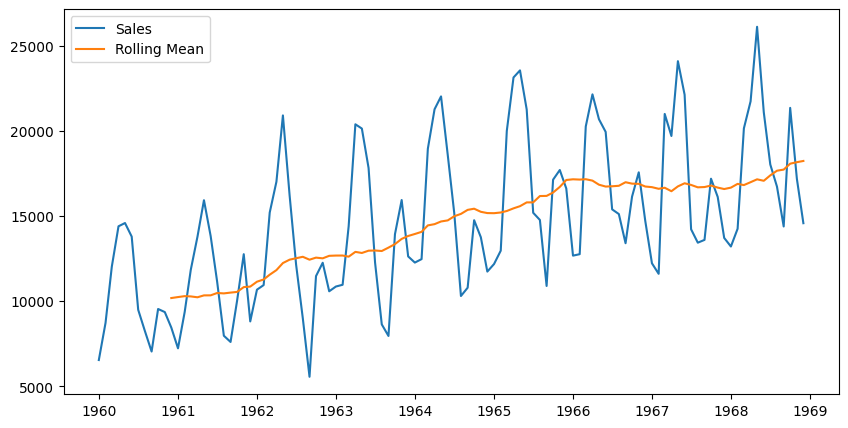

In [7]:
df['RollingMean']=df['Sales'].rolling(12).mean()

plt.figure(figsize=(10,5))
plt.plot(df['Sales'])
plt.plot(df['RollingMean'])
plt.legend(['Sales','Rolling Mean'])
plt.show()

In [8]:
train = df[:-12]
test = df[-12:]

In [9]:
model = ARIMA(train['Sales'], order=(5,1,0))

model_fit = model.fit()

pred_arima = model_fit.forecast(steps=12)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [10]:
mae_arima = mean_absolute_error(test['Sales'], pred_arima)

rmse_arima = np.sqrt(
    mean_squared_error(test['Sales'], pred_arima)
)

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

ARIMA MAE: 4954.043396924734
ARIMA RMSE: 5869.840778848785


In [13]:
prophet_df = df.reset_index()[['Date', 'Sales']]

prophet_df.columns=['ds','y']

In [14]:
train_prophet = prophet_df[:-12]

model = Prophet()

model.fit(train_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [15]:
future = model.make_future_dataframe(
    periods=12,
    freq='M'
)

forecast = model.predict(future)

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [16]:
pred_prophet = forecast['yhat'].tail(12).values

actual = test['Sales'].values

mae_prophet = mean_absolute_error(
    actual,
    pred_prophet
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        actual,
        pred_prophet
    )
)

print("Prophet MAE:", mae_prophet)
print("Prophet RMSE:", rmse_prophet)

Prophet MAE: 1470.9995672832083
Prophet RMSE: 1750.075310169557


In [17]:
results = pd.DataFrame({
    'Model':['ARIMA','Prophet'],
    'MAE':[mae_arima,mae_prophet],
    'RMSE':[rmse_arima,rmse_prophet]
})

print(results)

     Model          MAE         RMSE
0    ARIMA  4954.043397  5869.840779
1  Prophet  1470.999567  1750.075310
